# Test the Turing module

In [2]:
# including packages
using LazyGrids, PyPlot, BenchmarkTools
using PSFModels, ImageFiltering, Statistics
# for Turing
using Turing,StatsPlots,PairPlots, CairoMakie

using Jens
using Jens:LensBase as LB
using Jens:LensUtils as LU
using Jens:LensFITS as LF
using Jens:LensGenerator as LG
using Jens:LensModel as Jmodel
using Jens:LightModel as Jlight
using Jens:LensPyPlot as Jplot

using Jens.LensModel:NIEkappa as NIEkappa
using Jens.LightModel:GaussianLight as GaussianLight

ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.


## Simulating the Lensed Images

In [3]:
xg, yg = LU.LensGrid(;xl=2., nx=51)

# Light Parameters
LightParaDict = Dict(:amp=>1., :sigma=>0.1,
                :xcentre=>0.03, :ycentre=>0.0)
# Gaussian Light Profile
SourceLight = GaussianLight.GaussianSphere(xg, yg;
             LightParaDict...);

LensParaDict = Dict(:b => 1., :s => 0.1,
 :q => 0.7, :varphi =>  - pi/6. ,
  :xcentre => 0.1, :ycentre => .0);

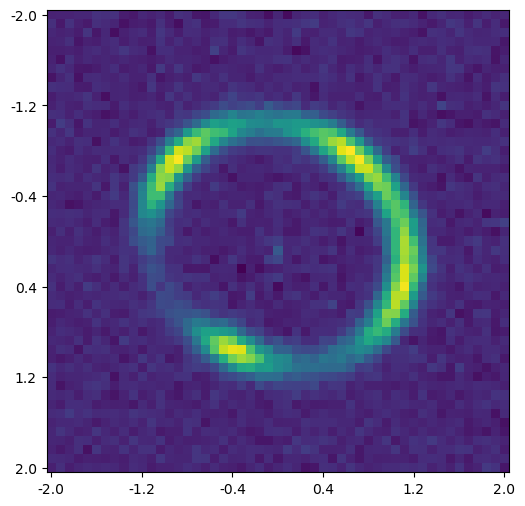

In [4]:
# Simulate the lensed image
data = LB.LensRayShooting(xg, yg; LensModel=NIEkappa, LensKwargs=LensParaDict
                            ,SourceProfile=GaussianLight.GaussianSphere,SourceKwargs=LightParaDict);
σ_noise = 0.5

data = data .+ rand(Normal(0, σ_noise), size(data))

LensFig, LensAx = Jplot.PlotPlane(xg, yg, data)
gcf()

In [259]:
plt.clf()

## Turing module

### set @model manually

For most generalized lensing parameter fittness, 
users are allowed to setting the lens parameters themselves, as  shown in the following model

In [260]:
@model function fit_lensed(x, y, data_obs)
    # Priors for parameters
    
    # set up the prior distributions for lens parameters
    # set NIEkappa's parameters via Normal distribution
    # truncated set the lower and upper bondary for distributions
    b ~ truncated(Normal(1., 1), 0, 5)
    s  ~ truncated(Normal(0., 1), 0, 0.1)
    q  ~ truncated(Normal(0.5, 1.0), 0.1, 1)
    varphi ~ truncated(Normal(-pi/6, 1), -pi, pi)
    xcentre ~ truncated(Normal(0, 1), -0.2, 0.2)
    ycentre ~ truncated(Normal(0, 1), -0.2, 0.2)
    
    ParaDict = Dict(:b => b, :s => s,
                :q => q, :varphi =>  varphi,
                :xcentre => xcentre, :ycentre => ycentre);
    
    # setup Lens light or Surce light if used

    # adapt a normal noise
    σ_noise ~ truncated(Normal(1, 1), 0, 5)

    # set up model
    model_intensity = LB.LensRayShooting(x, y; LensModel=NIEkappa, LensKwargs=ParaDict,
                        SourceProfile=GaussianLight.GaussianSphere, SourceKwargs=LightParaDict);

    # setup Likelihood
    for i in eachindex(data_obs)
        # only consider the value greater than background noise, s.t. noise = mean(data_obs)/5 here.
        if data_obs[i] > mean(data_obs)
            data_obs[i] ~ Normal(model_intensity[i], σ_noise)
        end
    end
end

fit_lensed (generic function with 2 methods)

In [261]:
chain = sample(fit_lensed(xg, yg, data),
         NUTS(400,0.65), 1000)#,  MCMCThreads(), 1000, 4)

Chains MCMC chain (1000×19×1 Array{Float64, 3}):

Iterations        = 401:1:1400
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 228.02 seconds
Compute duration  = 228.02 seconds
parameters        = b, s, q, varphi, xcentre, ycentre, σ_noise
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size

Summary Statistics
  parameters      mean       std      mcse    ess_bulk   ess_tail      rhat    ⋯
      Symbol   Float64   Float64   Float64     Float64    Float64   Float64    ⋯

           b    0.9982    0.0017    0.0001    558.9014   379.6764    1.0007    ⋯
           s    0.0982    0.0016    0.0001    445.0945   446.8565    1.0038    ⋯
           q    0.6998    0.0013    0.0001    728.4757   556.8542    1.0103    ⋯
      varphi   -0.5199    0.0026    0.0001   1348.0168   580.4478    1.0020    ⋯
     xcentre    0.1013    0.

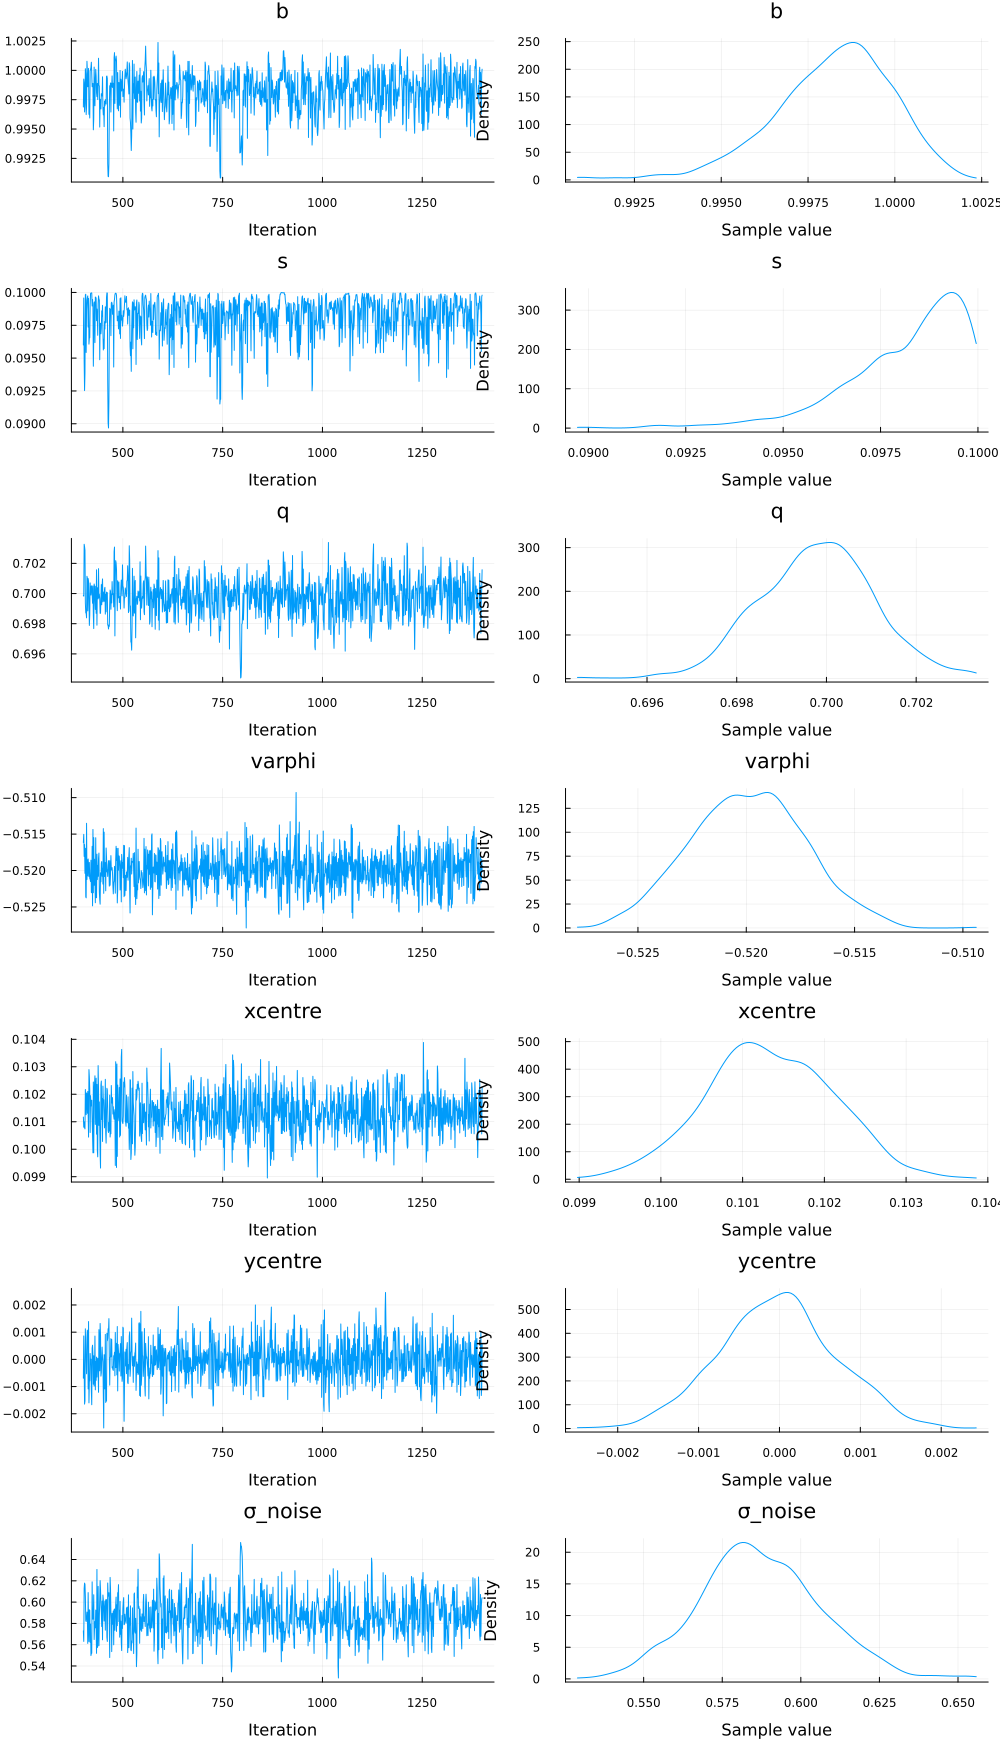

In [262]:
ChainPlot = StatsPlots.plot(chain)

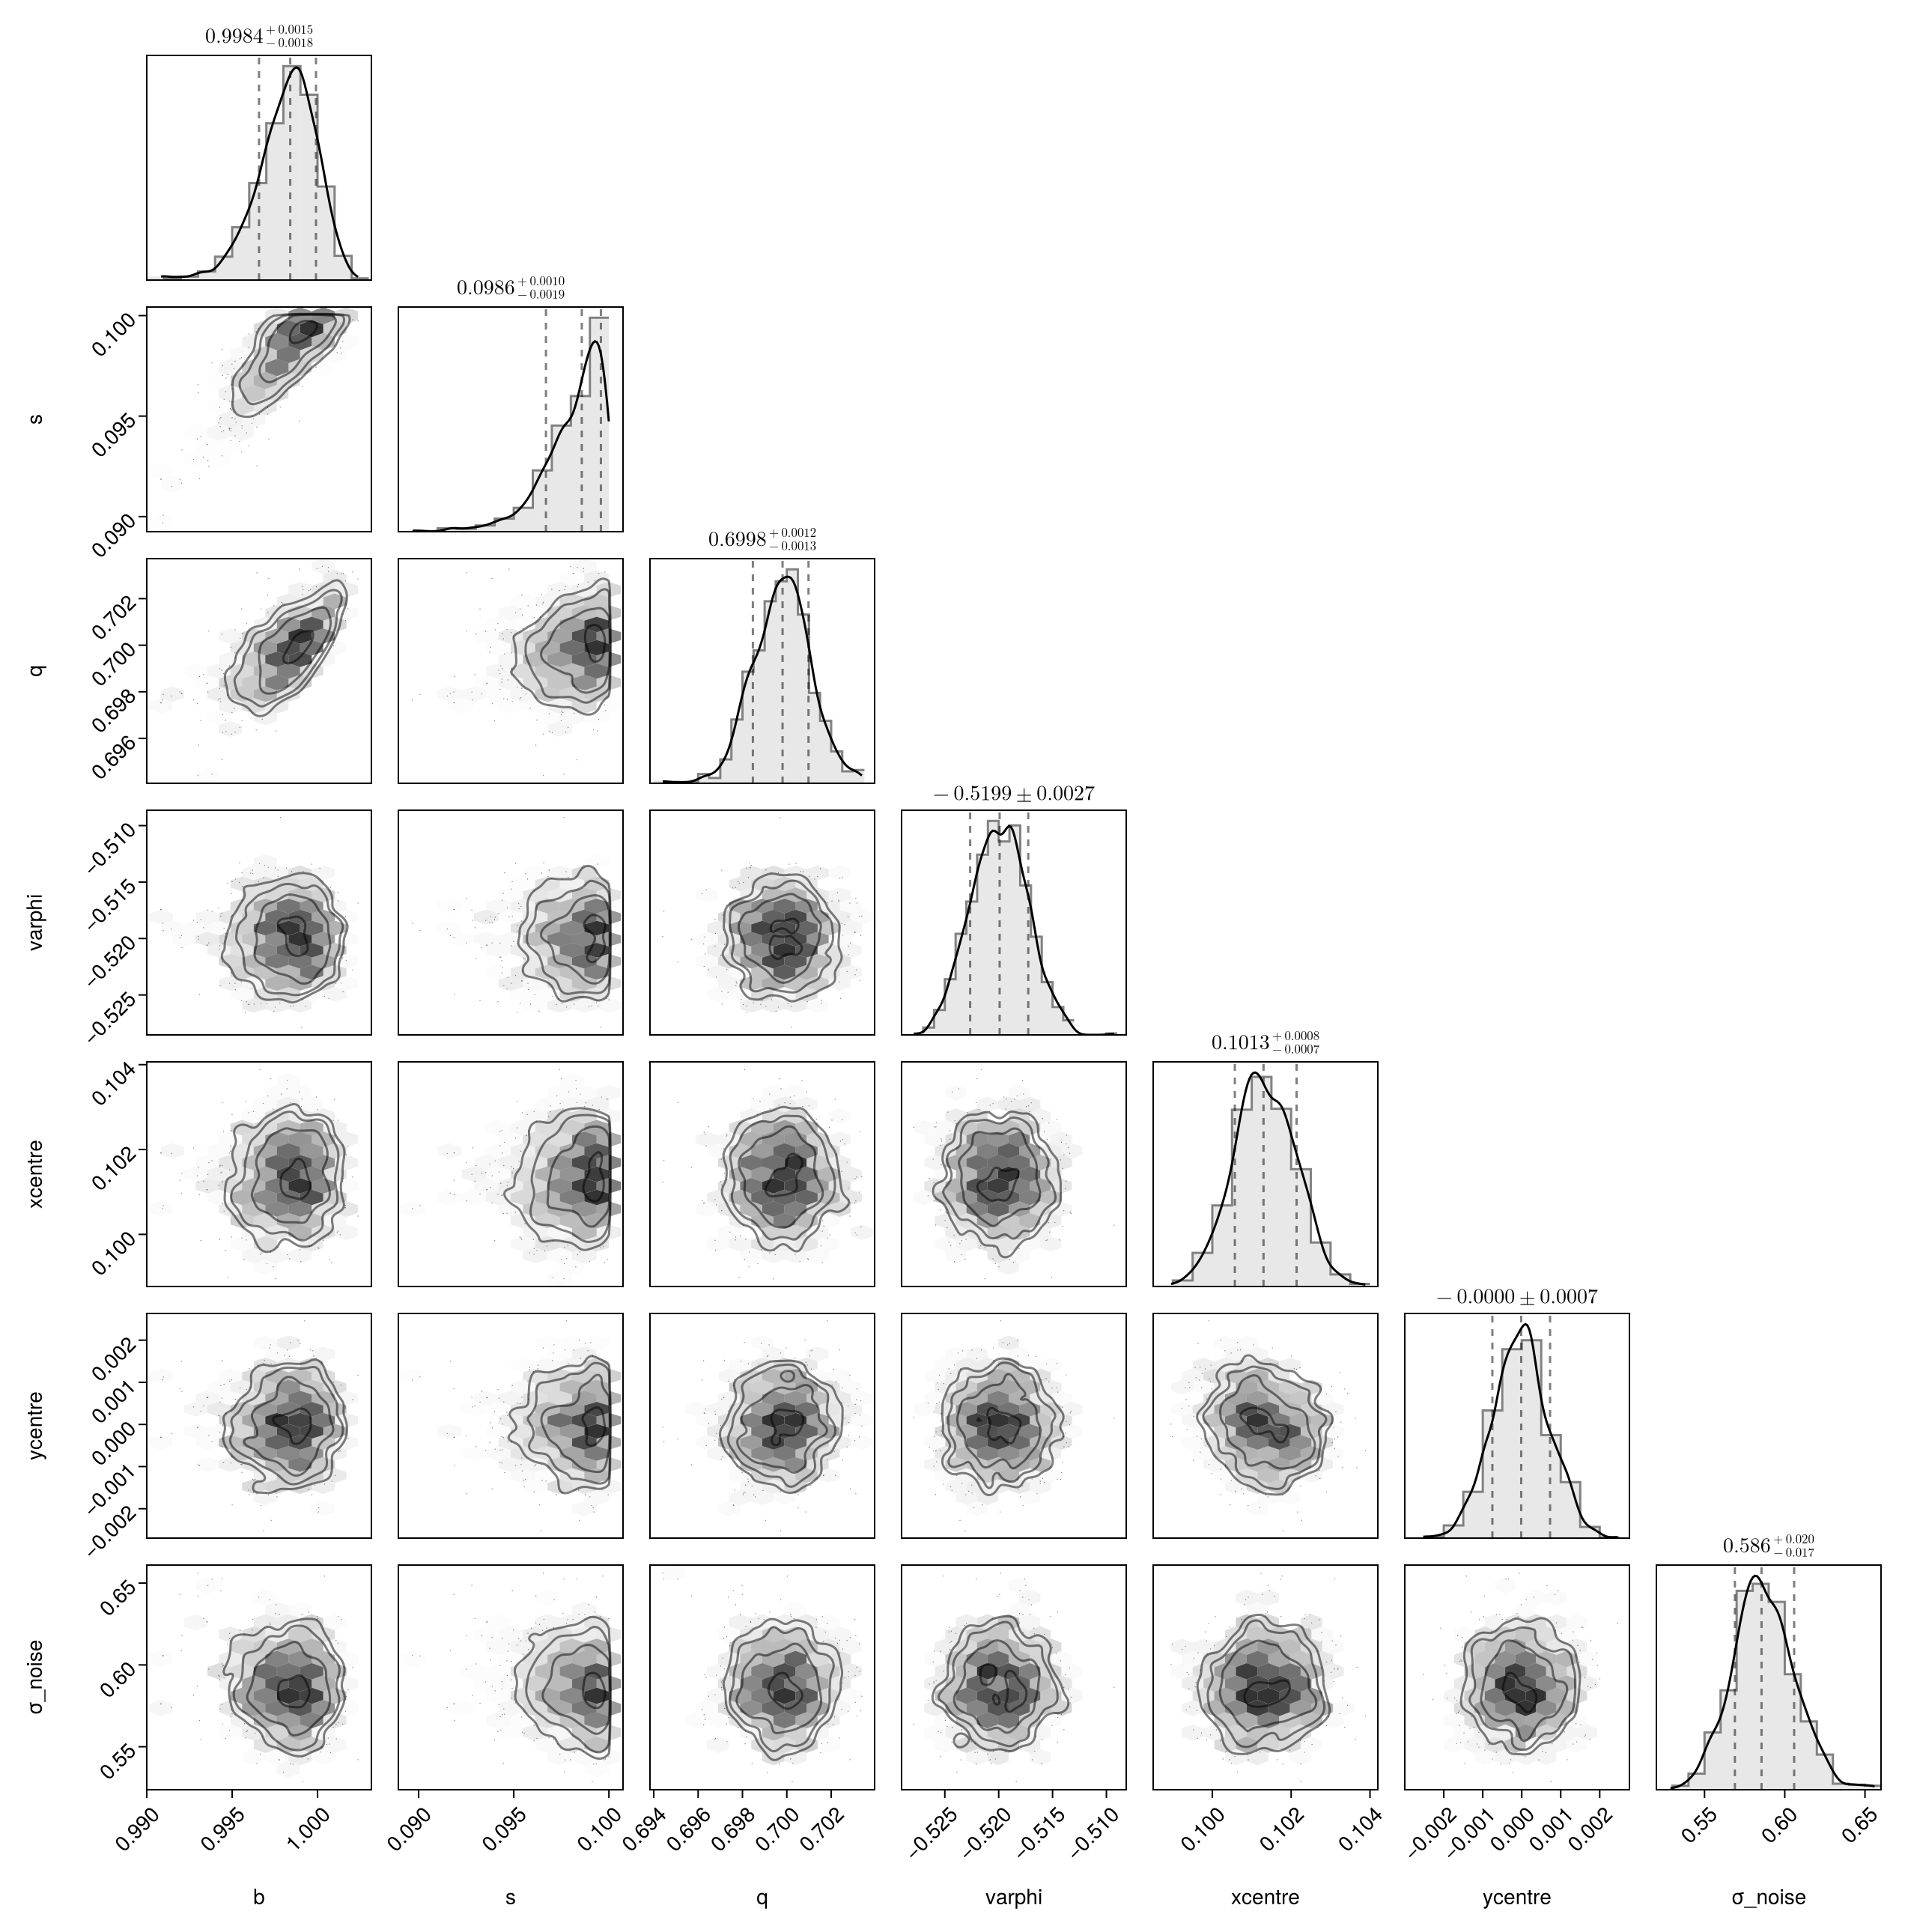

In [263]:
corner_fig = PairPlots.pairplot(chain)

In [264]:
mean_param = Dict([])
para_names = chain.name_map.parameters
for i in range(1,6)
    mean_param[para_names[i]] = mean(chain[:,i,1])
end

LensedLight = LB.LensRayShooting(xg, yg; LensModel=NIEkappa, LensKwargs=mean_param
                            ,SourceProfile=GaussianLight.GaussianSphere,SourceKwargs=LightParaDict);

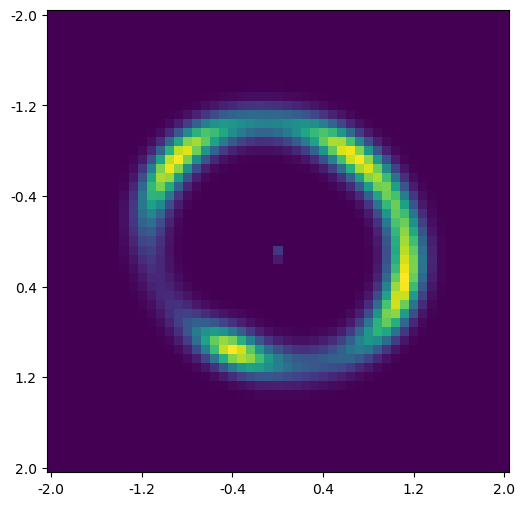

In [265]:
L3 = Jplot.PlotPlane(xg, yg, LensedLight)
gcf()

In [266]:
plt.clf()

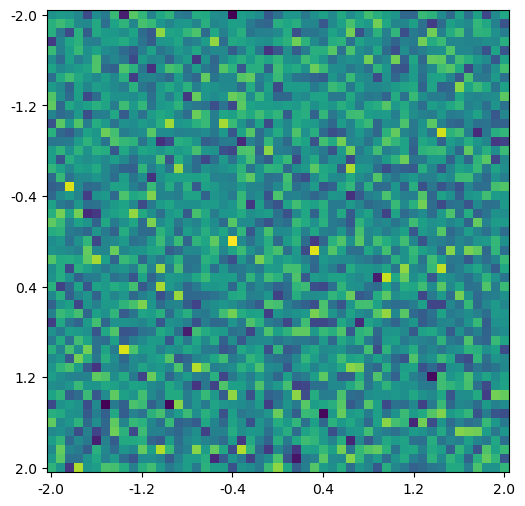

In [267]:
res = LensedLight - data
L4 = Jplot.PlotPlane(xg, yg, res)
gcf()

# Test on HE 0435-1223

### set @model with build-in functions

In [ ]:
#=
    b ~ truncated(Normal(1., 1), 0, 5)
    s  ~ truncated(Normal(0., 1), 0, 0.1)
    q  ~ truncated(Normal(0.5, 1.0), 0.1, 1)
    varphi ~ truncated(Normal(-pi/6, 1), -pi, pi)
    xcentre ~ truncated(Normal(0, 1), -0.2, 0.2)
    ycentre ~ truncated(Normal(0, 1), -0.2, 0.2)
=#
NIEKwargs_prior = Dict(
    :b => Dict(:mean=>1.0, :sigma=>1., :upper=>10., :lower=>0.0),
    :s => Dict(:mean=>0.05, :sigma=>1.0, :upper=>0.1, :lower=>0.01),
    :q => Dict(:mean=>0.5, :sigma=>1.0, :upper=>0.9, :lower=>0.01),
    :varphi => Dict(:mean=> -pi/6, :sigma=>1., :upper=>pi, :lower=> -pi),
    :xcentre => Dict(:mean=>0, :sigma=>1., :upper=>0.2, :lower=>-0.2),
    :ycentre => Dict(:mean=>0, :sigma=>1., :upper=>0.2, :lower=>-0.2),
)

# Light Parameters
LightParaDict = Dict(:amp=>1., :sigma=>0.1,
                :xcentre=>0.03, :ycentre=>0.0)



modelname = "NIEkappa"
LensModelKwargs = Dict(modelname=>NIEKwargs_prior)

In [ ]:
function make_dist(spec)
        mean, sigma = spec.mean, spec.sigma
        if haskey(spec, :lower)
            lower = spec.lower
        else
            lower = -Inf
        end
        if haskey(spec, :upper)
            upper = spec.upper
        else
            upper=Inf
        end
        return truncated(Normal(mean, sigma), lower, upper)

    end

@model function prior_model(specs)
    prior = Dict{Symbol, Any}()
    for (k, v) in specs
        if v isa NamedTuple
            prior[k] ~ make_dist(v)
        else
            prior[k] = v   # fixed
        end
    end
    print(typeof(prior))
    return prior 
end

@model function _model(x, y, specs)
    # declare params explicitly
    params = Dict{Symbol, Any}()

    params = prior_model(specs)

    # noise parameter
    σ ~ truncated(Normal(0, 1), 1e-6, Inf)

    # likelihood
    μ = f.(x; (params...)...)
    y .~ Normal.(μ, σ)
end

In [ ]:
@model function make_dist(Priors)
        Params = Dict{Symbol, Any}()
        for (name, spec) in Priors
            if spec isa Dict
                if haskey(spec, :mean) && haskey(spec, :sigma) && haskey(spec, :lower) && haskey(spec, :upper)
                    mean  = spec[:mean]
                    sigma = spec[:sigma]
                    lower = spec[:lower]
                    upper = spec[:upper]
                    para ~ truncated(Normal(mean, sigma), lower, upper)
                    Params[name] = para
                elseif haskey(spec, :mean) && haskey(spec, :sigma)
                    mean  = spec[:mean]
                    sigma = spec[:sigma]
                    para ~ Normal(mean, sigma)
                    Params[name] = para
                elseif haskey(spec, :lower) && haskey(spec, :upper)
                    lower = spec[:lower]
                    upper = spec[:upper]
                    para ~ Uniform(lower, upper)
                    Params[name] = para
                else
                    error("Unsupported prior for $name")
                end
            else
                # fixed parameter
                Params[name] = spec
            end
        end
        return Params

    end

In [ ]:
dist = make_dist(NIEKwargs_prior)

In [268]:
function BuildTuringsModel( x::AbstractArray, y::AbstractArray, data_obs::AbstractArray, LensPriors::Dict,
         SoourceLightPriors::Dict)

    @model function single_lens_model(x, y, data_obs)

        # --- Lens Priors ---
        ParaDict = Dict{Symbol, Any}()
        for (name, spec) in LensPriors
            if spec isa Dict
                if haskey(spec, :mean) && haskey(spec, :sigma) && haskey(spec, :lower) && haskey(spec, :upper)
                    mean  = spec[:mean]
                    sigma = spec[:sigma]
                    lower = spec[:lower]
                    upper = spec[:upper]
                    para ~ truncated(Normal(mean, sigma), lower, upper)
                    ParaDict[name] = para
                elseif haskey(spec, :mean) && haskey(spec, :sigma)
                    mean  = spec[:mean]
                    sigma = spec[:sigma]
                    para ~ Normal(mean, sigma)
                    ParaDict[name] = para
                elseif haskey(spec, :lower) && haskey(spec, :upper)
                    lower = spec[:lower]
                    upper = spec[:upper]
                    para ~ Uniform(lower, upper)
                    ParaDict[name] = para
                else
                    error("Unsupported prior for $name")
                end
            else
                # fixed parameter
                ParaDict[name] = spec
            end
        end


        # --- Lens Light Priors ---


        # --- Source Light Priors ---
        LightParaDict = Dict{Symbol, Any}()
        for (name, spec) in SourcePriors
            if spec isa Dict
                if haskey(spec, :mean) && haskey(spec, :sigma) && haskey(spec, :lower) && haskey(spec, :upper)
                    mean  = spec[:mean]
                    sigma = spec[:sigma]
                    lower = spec[:lower]
                    upper = spec[:upper]
                    para ~ truncated(Normal(mean, sigma), lower, upper)
                    LightParaDict[name] = para
                elseif haskey(spec, :mean) && haskey(spec, :sigma)
                    mean  = spec[:mean]
                    sigma = spec[:sigma]
                    para ~ Normal(mean, sigma)
                    LightParaDict[name] = para
                elseif haskey(spec, :lower) && haskey(spec, :upper)
                    lower = spec[:lower]
                    upper = spec[:upper]
                    para ~ Uniform(lower, upper)
                    LightParaDict[name] = para
                else
                    error("Unsupported prior for $name")
                end
            else
                # fixed parameter
                LightParaDict[name] = spec
            end
        end

        # --- Lens Modelling ---
        
        # adapt a normal noise
        σ_noise ~ truncated(Normal(1, 1), 0, 5)

        # set up model
        model_intensity = LB.LensRayShooting(x, y; LensModel=NIEkappa, LensKwargs=ParaDict,
                            SourceProfile=GaussianLight.GaussianSphere, SourceKwargs=LightParaDict);
    

        # --- Likelihood ---

        for i in eachindex(data_obs)
        # only consider the value greater than background noise, s.t. noise = mean(data_obs)/5 here.
            if data_obs[i] > mean(data_obs)
                data_obs[i] ~ Normal(model_intensity[i], σ_noise)
            end
        end
    end
    
    return single_lens_model(x, y, data)
end


BuildTuringsModel (generic function with 8 methods)

In [269]:
single_lens = BuildTuringsModel(xg, yg, data, NIEKwargs_prior, LightParaDict)

DynamicPPL.Model{var"#single_lens_model#52"{Dict{Symbol, Dict{Symbol}}}, (:x, :y, :data_obs), (), (), Tuple{LazyGrids.GridSL{Float64, 1, 2, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}}, LazyGrids.GridSL{Float64, 2, 2, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}}, Matrix{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(var"#single_lens_model#52"{Dict{Symbol, Dict{Symbol}}}(Dict{Symbol, Dict{Symbol}}(:b => Dict(:mean => 1.0, :upper => 10.0, :lower => 0.0, :sigma => 1.0), :s => Dict(:mean => 0.05, :upper => 0.1, :lower => 0.01, :sigma => 1.0), :varphi => Dict{Symbol, Real}(:mean => -0.5235987755982988, :upper => π, :lower => -3.141592653589793, :sigma => 1.0), :q => Dict(:mean => 0.5, :upper => 0.9, :lower => 0.01, :sigma => 1.0), :xcentre => Dict{Symbol, Real}(:mean => 0, :upper => 0.2, :lower => -0.2, :sigma => 1.0), :ycentre => Dict{Symbol, Real}(:mean => 0, :upper => 0.2, :lower => -0.2, :sigma => 1.0)), Core.Box(var"#single_lens_model#52"{Dict{Symbol, Dict

In [270]:
chain = sampler(single_lens(xg, yg, data), 
        NUTS(400,0.65), 1000)#,  MCMCThreads(), 1000, 4)

MethodError: MethodError: no method matching evaluate!!(::DynamicPPL.Model{var"#single_lens_model#52"{Dict{Symbol, Dict{Symbol}}}, (:x, :y, :data_obs), (), (), Tuple{LazyGrids.GridSL{Float64, 1, 2, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}}, LazyGrids.GridSL{Float64, 2, 2, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}}, Matrix{Float64}}, Tuple{}, DynamicPPL.DefaultContext}, ::LazyGrids.GridSL{Float64, 1, 2, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}}, ::LazyGrids.GridSL{Float64, 2, 2, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}}, ::Matrix{Float64})

Closest candidates are:
  evaluate!!(::DynamicPPL.Model, !Matched::Random.AbstractRNG)
   @ DynamicPPL ~/.julia/packages/DynamicPPL/cjQWO/src/model.jl:838
  evaluate!!(::DynamicPPL.Model, !Matched::Random.AbstractRNG, !Matched::DynamicPPL.AbstractVarInfo)
   @ DynamicPPL ~/.julia/packages/DynamicPPL/cjQWO/src/model.jl:838
  evaluate!!(::DynamicPPL.Model, !Matched::Random.AbstractR

In [ ]:
LensParams = Dict{Symbol, Any}()
for (name, spec) in NIEKwargs_prior
    if spec isa Dict
        # sampled parameter
        if haskey(spec, :mean) && haskey(spec, :sigma) && haskey(spec, :lower) && haskey(spec, :upper)
            LensParams[name] ~ truncated(Normal(spec[:mean], spec[:sigma]), spec[:lower], spec[:upper])
        elseif haskey(spec, :mean) && haskey(spec, :sigma)
            LensParams[name] ~ Normal(spec[:lower], spec[:upper])
        elseif haskey(spec, :lower) && haskey(spec, :upper)
            LensParams[name] ~ Uniform(spec[:lower], spec[:upper])
        else
            error("Unsupported prior for $name")
        end
    else
        # fixed parameter
        LensParams[name] = spec
    end
end

In [ ]:
priors = Dict(
    :μ => Dict(:mean => 0.0, :sigma => 1.0),
    :σ => Dict(:lower => 0.0, :upper => 5.0)
)

# Likelihood: Normal(μ, σ)
likelihood = Dict(:dist => :Normal, :params => [:μ, :σ])

# Fake data
data = rand(Normal(1.5, 2.0), 100)

# Build model
model = build_model(priors, likelihood, data)

# Sample
chain = sample(model, NUTS(), 1000)

In [ ]:
function prior_test(arg_symbols, LensModelKwargs)

    model = keys(LensModelKwargs)
    LensModelKwargs_mean = LensModelKwargs[model]["LensModelKwargs_mean"]
    LensModelKwargs_sigma = LensModelKwargs[model]["LensModelKwargs_sigma"]
    LensModelKwargs_upper = LensModelKwargs[model]["LensModelKwargs_upper"]
    LensModelKwargs_lower = LensModelKwargs[model]["LensModelKwargs_lower"]
    new_dict = Dict()
    for sym in keys(LensModelKwargs["LensModelKwargs_mean"])
        temp ~ truncated(Normal(LensModelKwargs_mean[sym], LensModelKwargs_sigma[sym]),
                        LensModelKwargs_lower[sym], LensModelKwargs_upper[sym])
        new_dict[sym] = temp
    end

    print(new_dict)
    return new_dict
end

In [ ]:
@model function fit_lensed(x, y, data_obs; binit=1., bmin=0, bmax=5.)

    # Priors for parameters
    
    # set up the prior distributions for lens parameters
    # set NIEkappa's parameters via Normal distribution
    # truncated set the lower and upper bondary for distributions
    b ~ truncated(Normal(1., 1), 0, 5)
    s  ~ truncated(Normal(0., 1), 0, 0.1)
    q  ~ truncated(Normal(0.5, 1.0), 0.1, 1)
    varphi ~ truncated(Normal(-pi/6, 1), -pi, pi)
    xcentre ~ truncated(Normal(0, 1), -0.2, 0.2)
    ycentre ~ truncated(Normal(0, 1), -0.2, 0.2)
    
    ParaDict = Dict(:b => b, :s => s,
                :q => q, :varphi =>  varphi,
                :xcentre => xcentre, :ycentre => ycentre);
    
    # setup Lens light or Surce light if used

    # adapt a normal noise
    σ_noise ~ truncated(Normal(1, 1), 0, 5)

    # set up model
    model_intensity = LB.LensRayShooting(x, y; LensModel=NIEkappa, LensKwargs=ParaDict,
                        SourceProfile=GaussianLight.GaussianSphere, SourceKwargs=LightParaDict);

    # setup Likelihood
    for i in eachindex(data_obs)
        # only consider the value greater than background noise, s.t. noise = mean(data_obs)/5 here.
        if data_obs[i] > mean(data_obs)
            data_obs[i] ~ Normal(model_intensity[i], σ_noise)
        end
    end
end

In [254]:
using Turing, Distributions

# --- 1) Turn your mean/sigma/lower/upper specs into distribution objects ---
function build_dist_dict(specs::Dict{Symbol,Dict})
    Dict(k => (
        v = specs[k];
        # use truncated Normal when any bound exists, else plain Normal
        if haskey(v, :lower) || haskey(v, :upper)
            lo = get(v, :lower, -Inf)
            hi = get(v, :upper,  Inf)
            truncated(Normal(v[:mean], v[:sigma]), lo, hi)
        else
            Normal(v[:mean], v[:sigma])
        end
    ) for k in keys(specs))
end

# --- 2) Make an auto-model generator ---
# `priors_dists` is a Dict{Symbol,Distribution} (produced by build_dist_dict).
# `likelihood_body` is an Expr that refers to the parameter names (symbols) you expect.
function make_auto_model(priors_dists::Dict{Symbol,<:Distribution}, likelihood_body::Expr)
    # create parameter sampling expressions like:  b ~ priors[:b]
    assigns = [ :( $(Symbol(k)) ~ priors[$(QuoteNode(k))] ) for k in keys(priors_dists) ]

    # pick a unique function name to avoid method redefinition warnings
    fname = gensym(:auto_model)

    # build the @model function expression and eval it into global scope
    ex = quote
        @model function $(fname)(priors, x, y)
            $(assigns...)           # spliced param sampling lines
            $(likelihood_body)      # spliced likelihood block (uses b, s, q, ...)
        end
    end

    eval(ex)                   # define the function in global scope
    return eval(fname)         # return the function object (callable)
end

# --- 3) Example using your NIEKwargs_prior ---
NIEKwargs_prior = Dict(
    :b => Dict(:mean=>1.0, :sigma=>1., :upper=>10., :lower=>0.0),
    :s => Dict(:mean=>0.05, :sigma=>1.0, :upper=>0.1, :lower=>0.01),
    :q => Dict(:mean=>0.5, :sigma=>1.0, :upper=>0.9, :lower=>0.01),
    :varphi => Dict(:mean=> -pi/6, :sigma=>1., :upper=>pi, :lower=> -pi),
    :xcentre => Dict(:mean=>0, :sigma=>1., :upper=>0.2, :lower=>-0.2),
    :ycentre => Dict(:mean=>0, :sigma=>1., :upper=>0.2, :lower=>-0.2),
)

# build distributions
priors_dists = build_dist_dict(NIEKwargs_prior)

# define likelihood body as an Expr (must use the same param names b, s, q, ...)
likelihood_block = quote
    # example: user-defined forward model using the parameters
    μ = b .* x .+ s             # replace with your real forward function
    for i in eachindex(x)
        y[i] ~ Normal(μ[i], 0.05)
    end
end

# create the model factory (returns a function you call to get a model instance)
auto_model = make_auto_model(priors_dists, likelihood_block)

# IMPORTANT: call auto_model with (priors_dict, x, y)
x = collect(0.1:0.1:2.0)
y = rand(Normal(1.0, 0.05), length(x))

model_instance = auto_model(priors_dists, x, y)   # <- correct call signature
chain = sample(model_instance, NUTS(), 500)


MethodError: MethodError: no method matching build_dist_dict(::Dict{Symbol, Dict{Symbol}})

Closest candidates are:
  build_dist_dict(!Matched::Dict{Symbol, Dict})
   @ Main ~/Documents/VScodeProjects/Jens/Jens/test/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y134sZmlsZQ==.jl:4
